# Five-minute unfiltered Hall-array acquisition and PSD

This notebook records all 36 channels for 300 seconds, converts the received ADC values directly to volts, and computes ensemble averages and PSDs from the board's natural output voltage.

All saved data, plots, ensemble averages, and PSDs use the board's natural output voltage. No DC removal, moving average, smoothing, windowing, or Welch averaging is applied.

**Hardware limitation:** the current camera firmware calls `super_frame(frame, 64)`, so every transmitted frame is already the average of 64 ADC scans. That device-side averaging cannot be undone here without changing and reflashing the firmware.

## 1. Imports and acquisition settings

Run the notebook with an environment containing NumPy, Matplotlib, pySerial, and Jupyter. Change `PORT` if the array appears under another serial-device name. Leave `SAMPLE_RATE_HZ = None` to estimate the transmitted-frame rate from the five-minute capture. If you have independently measured the exact frame rate, enter it instead for the most accurate PSD frequency axis.

In [1]:
from pathlib import Path
from collections import deque
from datetime import datetime, timezone
import json
import time
import matplotlib.pyplot as plt
import numpy as np
import pyqtgraph as pg
import serial
from PyQt6.QtWidgets import (
    QApplication, QMainWindow, QWidget, QVBoxLayout, QHBoxLayout,
    QPushButton, QLabel,
)

PORT = "/dev/ttyACM0"
BAUDRATE = 921600
SAMPLE_RATE_HZ = None  # None = estimate the output-frame rate from the capture

NUM_CHANNELS = 36
SYNC_BYTES = b"\xAA\x55\xAA\x55"
PAYLOAD_SIZE = NUM_CHANNELS * 2
RAW_SHIFT = 4
V_REF = 5.0
ADC_FULL_SCALE = 1 << 12
VOLTS_PER_COUNT = V_REF / ADC_FULL_SCALE



OUTPUT_DIR = Path("hall_array_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)
print(f"Results will be written to: {OUTPUT_DIR.resolve()}")

Results will be written to: /home/hamid/SuperHallArray/hall_array_output


## 2. Frame parser and five-minute capture

The parser uses the same byte-accurate synchronization and ADC scaling as the viewer. The serial input buffer is cleared immediately before acquisition so old frames are not included. Stop the cell with the notebook interrupt button if necessary; the serial port is still closed by the `finally` block.

In [2]:
class FrameParser:
    def __init__(self):
        self.buffer = bytearray()

    def feed(self, chunk):
        self.buffer.extend(chunk)
        frames = []
        frame_size = len(SYNC_BYTES) + PAYLOAD_SIZE

        while True:
            sync_index = self.buffer.find(SYNC_BYTES)
            if sync_index < 0:
                keep = len(SYNC_BYTES) - 1
                if len(self.buffer) > keep:
                    del self.buffer[:-keep]
                break
            if len(self.buffer) - sync_index < frame_size:
                del self.buffer[:sync_index]
                break

            payload_start = sync_index + len(SYNC_BYTES)
            payload_end = payload_start + PAYLOAD_SIZE
            wire_values = np.frombuffer(
                bytes(self.buffer[payload_start:payload_end]), dtype="<u2"
            ).copy()
            del self.buffer[:payload_end]
            frames.append(wire_values)

        return frames


class RawLiveSignalWindow:
    """Live display of raw transmitted frames; history is not averaged."""

    def __init__(self, title, history_length=800):
        self.app = QApplication.instance() or QApplication([])
        self.history = np.full((history_length, NUM_CHANNELS), np.nan)
        self.window = pg.GraphicsLayoutWidget(show=True, title=title)
        self.window.resize(1200, 700)
        self.plot = self.window.addPlot(title=title)
        self.plot.setLabel("bottom", "Raw transmitted frame")
        self.plot.setLabel("left", "Natural V_out [V]")
        self.plot.showGrid(x=True, y=True, alpha=0.25)
        colors = [pg.intColor(index, hues=NUM_CHANNELS) for index in range(NUM_CHANNELS)]
        self.curves = [self.plot.plot(pen=pg.mkPen(color, width=1)) for color in colors]
        self.app.processEvents()

    def update(self, wire_frame):
        raw_voltage_v = (
            wire_frame.astype(np.float64) / (1 << RAW_SHIFT) * VOLTS_PER_COUNT
        )
        self.history[:-1] = self.history[1:]
        self.history[-1] = raw_voltage_v
        for channel, curve in enumerate(self.curves):
            curve.setData(self.history[:, channel])
        self.app.processEvents()

    def close(self):
        self.window.close()
        self.app.processEvents()


class SensitivityLiveSignalWindow(RawLiveSignalWindow):
    """Baseline-referenced, rolling-display viewer for weak-field alignment."""

    def __init__(self, title, calibration_frames=500, display_window_frames=64):
        super().__init__(title)
        self.calibration_frames = calibration_frames
        self.display_window_frames = display_window_frames
        self.calibration_samples = []
        self.baseline_v = None
        self.display_samples = deque(maxlen=display_window_frames)
        self.plot.setLabel("left", "Baseline-referenced V_out [V]")
        self.plot.setTitle("Collecting baseline: keep magnet at 50 cm")

    @property
    def calibrated(self):
        return self.baseline_v is not None

    def update(self, wire_frame):
        raw_voltage_v = (
            wire_frame.astype(np.float64) / (1 << RAW_SHIFT) * VOLTS_PER_COUNT
        )
        if not self.calibrated:
            self.calibration_samples.append(raw_voltage_v)
            if len(self.calibration_samples) >= self.calibration_frames:
                self.baseline_v = np.mean(self.calibration_samples, axis=0)
                self.plot.setTitle(
                    f"Baseline set. Live display: {self.display_window_frames}-frame rolling average"
                )
            self.app.processEvents()
            return

        # This average is display-only. Raw values remain the saved measurements.
        self.display_samples.append(raw_voltage_v - self.baseline_v)
        display_voltage_v = np.mean(self.display_samples, axis=0)
        self.history[:-1] = self.history[1:]
        self.history[-1] = display_voltage_v
        for channel, curve in enumerate(self.curves):
            curve.setData(self.history[:, channel])
        self.app.processEvents()


In [ ]:
DURATION_S = 5 * 60
def acquire_frames(port, baudrate, duration_s):
    parser = FrameParser()
    wire_frames = []
    arrival_times_s = []

    with serial.Serial(port, baudrate, timeout=0.1) as ser:
        ser.reset_input_buffer()
        # This window displays the raw received frames; it does not average them.
        global five_minute_live_viewer
        five_minute_live_viewer = RawLiveSignalWindow(
            "Live raw Hall-array signals — five-minute capture"
        )
        start = time.perf_counter()
        next_report = start + 10

        while True:
            now = time.perf_counter()
            if now - start >= duration_s:
                break

            chunk = ser.read(max(ser.in_waiting, 1))
            if chunk:
                parsed = parser.feed(chunk)
                received_at = time.perf_counter() - start
                for raw_frame in parsed:
                    five_minute_live_viewer.update(raw_frame)
                wire_frames.extend(parsed)
                arrival_times_s.extend([received_at] * len(parsed))

            if now >= next_report:
                elapsed = now - start
                print(
                    f"{elapsed:6.1f}/{duration_s:.0f} s, "
                    f"{len(wire_frames):,} frames received"
                )
                next_report += 10.0

        capture_elapsed_s = time.perf_counter() - start

    if len(wire_frames) < 2:
        raise RuntimeError(
            f"Only {len(wire_frames)} frame(s) were received from {port}. "
            "Check the port, firmware mode, and USB connection."
        )

    return (
        np.asarray(wire_frames, dtype=np.uint16),
        np.asarray(arrival_times_s, dtype=np.float64),
        capture_elapsed_s,
    )


wire_values, arrival_times_s, capture_elapsed_s = acquire_frames(
    PORT, BAUDRATE, DURATION_S
)

# Q4 wire values -> fractional 12-bit ADC counts -> physical output volts.
# This is direct scaling only: no baseline removal and no host-side filtering.
adc_counts = wire_values.astype(np.float64) / (1 << RAW_SHIFT)
voltage_out = adc_counts * VOLTS_PER_COUNT

if SAMPLE_RATE_HZ is None:
    measured_sample_rate_hz = (len(voltage_out) - 1) / (
        arrival_times_s[-1] - arrival_times_s[0]
    )
    sample_rate_hz = measured_sample_rate_hz
    sample_rate_source = "estimated from host arrival time"
else:
    sample_rate_hz = float(SAMPLE_RATE_HZ)
    measured_sample_rate_hz = (len(voltage_out) - 1) / (
        arrival_times_s[-1] - arrival_times_s[0]
    )
    sample_rate_source = "user supplied"

if not np.isfinite(sample_rate_hz) or sample_rate_hz <= 0:
    raise RuntimeError(f"Invalid sample rate: {sample_rate_hz}")

# Frames do not contain device timestamps. Use a uniform time base at the selected
# output-frame rate, as required by the FFT PSD.
time_s = np.arange(len(voltage_out), dtype=np.float64) / sample_rate_hz

print(f"Captured {len(voltage_out):,} frames in {capture_elapsed_s:.3f} s")
print(f"Measured output-frame rate: {measured_sample_rate_hz:.6f} Hz")
print(f"PSD/time-axis rate: {sample_rate_hz:.6f} Hz ({sample_rate_source})")
print(f"Voltage array shape: {voltage_out.shape}")

## 3. Save the natural board-voltage samples

The natural-voltage time series is saved as CSV. No NPZ files are written.

In [ ]:
csv_path = OUTPUT_DIR / "hall_array_5min_unfiltered.csv"
csv_data = np.column_stack((time_s, voltage_out))
csv_header = "time_s," + ",".join(
    f"pad_{index:02d}_voltage_out_v" for index in range(1, NUM_CHANNELS + 1)
)
np.savetxt(csv_path, csv_data, delimiter=",", header=csv_header, comments="")

metadata = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "port": PORT,
    "baudrate": BAUDRATE,
    "requested_duration_s": DURATION_S,
    "actual_capture_elapsed_s": capture_elapsed_s,
    "number_of_frames": len(voltage_out),
    "number_of_channels": NUM_CHANNELS,
    "measured_output_frame_rate_hz": measured_sample_rate_hz,
    "psd_sample_rate_hz": sample_rate_hz,
    "sample_rate_source": sample_rate_source,
    "volts_per_adc_count": VOLTS_PER_COUNT,
    "host_filtering": "none",
    "baseline_subtracted": False,
    "firmware_note": "Current camera firmware averages 64 ADC scans per transmitted frame.",
}
metadata_path = OUTPUT_DIR / "metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2) + "\n", encoding="utf-8")

print(f"Saved {csv_path}")
print(f"Saved {metadata_path}")

## 4. Plot and save natural voltage versus time for all 36 pads

In [ ]:
fig, axes = plt.subplots(6, 6, figsize=(20, 15), sharex=True, constrained_layout=True)
for channel, ax in enumerate(axes.flat):
    ax.plot(time_s, voltage_out[:, channel], linewidth=0.55)
    ax.set_title(f"Pad {channel + 1}", fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))
    if channel // 6 == 5:
        ax.set_xlabel("Time [s]")
    if channel % 6 == 0:
        ax.set_ylabel("Voltage out [V]")

fig.suptitle(
    f"Natural Hall-array voltage — {capture_elapsed_s:.1f} s capture",
    fontsize=15,
)
timeseries_plot_path = OUTPUT_DIR / "voltage_out_36_pads_5min.png"
fig.savefig(timeseries_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {timeseries_plot_path}")

### Natural voltage comparison in one time-series plot

This plot overlays the natural output voltage of all 36 pads, including their stable approximately 2.5 V offsets.

In [ ]:
# Plot the natural output voltage of all 36 pads on one set of axes.
fig, ax = plt.subplots(figsize=(16, 9), constrained_layout=True)
colors = plt.cm.turbo(np.linspace(0.0, 1.0, NUM_CHANNELS))
for channel, color in enumerate(colors):
    ax.plot(
        time_s,
        voltage_out[:, channel],
        color=color,
        linewidth=0.7,
        alpha=0.8,
        label=f"Pad {channel + 1}",
    )

ax.set_xlabel("Time [s]")
ax.set_ylabel(r"Natural $V_{out}$ [V]")
ax.set_title("Natural voltage versus time for all 36 Hall-array pads")
ax.grid(True, alpha=0.3)
ax.legend(title="Channels", bbox_to_anchor=(1.01, 1.0), loc="upper left", ncol=2, fontsize=7)

actual_voltage_plot_path = OUTPUT_DIR / "natural_voltage_all_36_pads_timeseries.png"
fig.savefig(actual_voltage_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {actual_voltage_plot_path}")

## 5. Ensemble average of all 36 pads

At every time point, the ensemble output is the equal-weight arithmetic mean of the 36 simultaneous natural pad voltages. This is an average across pads, not a moving average across time.

In [ ]:
# Ensemble average across the 36 pads for every acquired frame.
ensemble_average_v = voltage_out.mean(axis=1)

# Save the exact time and ensemble-average values used in the plot.
ensemble_csv_path = OUTPUT_DIR / "ensemble_average_36_pads.csv"
ensemble_table = np.column_stack((time_s, ensemble_average_v))
np.savetxt(
    ensemble_csv_path,
    ensemble_table,
    delimiter=",",
    header="time_s,ensemble_average_voltage_v",
    comments="",
)

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
ax.plot(time_s, ensemble_average_v, color="blue", linewidth=0.9)
ax.set_xlabel("Time [s]")
ax.set_ylabel(r"Ensemble-average $V_{out}$ [V]")
ax.set_title("Ensemble average of all 36 natural Hall-array pads")
ax.grid(True, alpha=0.3)

ensemble_plot_path = OUTPUT_DIR / "ensemble_average_36_pads.png"
fig.savefig(ensemble_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Ensemble mean: {ensemble_average_v.mean():.6f} V")
print(f"Saved {ensemble_csv_path}")
print(f"Saved {ensemble_plot_path}")

## 6. PSD of the natural 36-pad ensemble average

This cell plots power spectral density in V²/Hz versus frequency for the ensemble average of the natural pad voltages.

In [ ]:
# Use the natural ensemble-average voltage without DC removal.
ensemble_signal_v = ensemble_average_v
ensemble_sample_count = len(ensemble_signal_v)
ensemble_frequency_hz = np.fft.rfftfreq(
    ensemble_sample_count, d=1.0 / sample_rate_hz
)
ensemble_fft = np.fft.rfft(ensemble_signal_v)
ensemble_psd_v2_per_hz = (np.abs(ensemble_fft) ** 2) / (
    sample_rate_hz * ensemble_sample_count
)

# Convert to a one-sided PSD. DC and Nyquist are not doubled.
if ensemble_sample_count % 2 == 0:
    ensemble_psd_v2_per_hz[1:-1] *= 2.0
else:
    ensemble_psd_v2_per_hz[1:] *= 2.0
ensemble_psd_v2_per_hz = np.maximum(ensemble_psd_v2_per_hz, 0.0)

# Save exactly the same frequency and V²/Hz values used in the plot.
ensemble_psd_csv_path = OUTPUT_DIR / "ensemble_average_psd.csv"
np.savetxt(
    ensemble_psd_csv_path,
    np.column_stack((ensemble_frequency_hz, ensemble_psd_v2_per_hz)),
    delimiter=",",
    header="frequency_hz,ensemble_average_psd_v2_per_hz",
    comments="",
)

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
ax.plot(ensemble_frequency_hz, ensemble_psd_v2_per_hz, color="blue", linewidth=0.9)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(r"Ensemble-average PSD [V²/Hz]")
ax.set_ylim(bottom=0.0)
ax.set_title("PSD of the natural 36-pad ensemble-average voltage")
ax.grid(True, alpha=0.3)

ensemble_psd_plot_path = OUTPUT_DIR / "ensemble_average_psd.png"
fig.savefig(ensemble_psd_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved {ensemble_psd_csv_path}")
print(f"Saved {ensemble_psd_plot_path}")

## 7. Calculate PSD for all 36 natural pad voltages

The natural pad voltages are used directly for the individual-channel PSD calculation. The 0 Hz component therefore includes the stable board-voltage offset.

In [ ]:
# Use the natural board-voltage samples directly; no DC removal or filtering.
voltage_for_psd_v = voltage_out
print("Using natural board-voltage samples; no DC removal or filtering.")

In [ ]:
# Calculate a one-sided PSD directly from the complete natural-voltage recording.
# This is a single FFT periodogram: no Welch/segment averaging or smoothing.
number_of_samples = len(voltage_for_psd_v)
psd_frequency_hz = np.fft.rfftfreq(number_of_samples, d=1.0 / sample_rate_hz)
voltage_fft = np.fft.rfft(voltage_for_psd_v, axis=0)
psd_v2_per_hz = (np.abs(voltage_fft) ** 2) / (sample_rate_hz * number_of_samples)

# Convert the two-sided result to a one-sided PSD. DC and Nyquist are not doubled.
if number_of_samples % 2 == 0:
    psd_v2_per_hz[1:-1] *= 2.0
else:
    psd_v2_per_hz[1:] *= 2.0
psd_v2_per_hz = np.maximum(psd_v2_per_hz, 0.0)

# Save the exact same frequency and PSD arrays used by the plot below.
psd_csv_path = OUTPUT_DIR / "psd_36_pads.csv"
psd_table = np.column_stack((psd_frequency_hz, psd_v2_per_hz))
psd_header = "frequency_hz," + ",".join(
    f"pad_{index:02d}_psd_v2_per_hz" for index in range(1, NUM_CHANNELS + 1)
)
np.savetxt(psd_csv_path, psd_table, delimiter=",", header=psd_header, comments="")

print(f"Frequency-bin spacing: {psd_frequency_hz[1] - psd_frequency_hz[0]:.6g} Hz")
print(f"Saved {psd_csv_path}")

## 8. Plot PSD for all 36 pads

This plot overlays the saved PSD of all 36 pads. Its unit is V²/Hz and it includes the natural stable DC voltage at 0 Hz.

In [ ]:
# Plot the PSD arrays saved by the preceding cell.
fig, ax = plt.subplots(figsize=(16, 9), constrained_layout=True)
colors = plt.cm.turbo(np.linspace(0.0, 1.0, NUM_CHANNELS))
for channel, color in enumerate(colors):
    ax.plot(
        psd_frequency_hz,
        psd_v2_per_hz[:, channel],
        color=color,
        linewidth=1.0,
        alpha=0.85,
        label=f"Pad {channel + 1}",
    )

ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(r"PSD of $V_{out}$ [V²/Hz]")
ax.set_ylim(bottom=0.0)
ax.set_title(f"Unaveraged PSD of all 36 natural Hall-array voltages (fs = {sample_rate_hz:.3f} Hz)")
ax.grid(True, alpha=0.3)
ax.legend(title="Channels", bbox_to_anchor=(1.01, 1.0), loc="upper left", ncol=2, fontsize=7)

psd_plot_path = OUTPUT_DIR / "psd_36_pads.png"
fig.savefig(psd_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved {psd_plot_path}")

## 9. Magnetic field sensitivity measurement

In [ ]:
# Magnetic-field sensitivity sweep: one raw frame from every pad per distance.
# At each printed distance, place the magnet and allow one second to settle.
# Saved measurements remain raw. The live display uses display-only baseline
# removal and rolling averaging to make weak distant-field changes visible.

SENSITIVITY_START_CM = 50
SENSITIVITY_STOP_CM = 0
SENSITIVITY_SETTLE_S = 2
SENSITIVITY_FRAME_TIMEOUT_S = 5
SENSITIVITY_BASELINE_FRAMES = 500
SENSITIVITY_DISPLAY_WINDOW_FRAMES = 64


def read_one_raw_frame(ser, parser, timeout_s):
    """Return the first complete transmitted frame received after this call."""
    deadline = time.perf_counter() + timeout_s
    while time.perf_counter() < deadline:
        chunk = ser.read(max(ser.in_waiting, 1))
        if not chunk:
            continue
        frames = parser.feed(chunk)
        if frames:
            return frames[0]
    raise TimeoutError(
        f"No complete Hall-array frame received within {timeout_s:.1f} s. "
        "Check the serial connection and firmware stream."
    )


sensitivity_distance_cm = np.arange(
    SENSITIVITY_START_CM, SENSITIVITY_STOP_CM - 1, -1, dtype=np.float64
)
sensitivity_wire_values = []

# Non-blocking reads keep the live display responsive at the frame rate.
with serial.Serial(PORT, BAUDRATE, timeout=0) as ser:
    # The display follows timeseries_ambient.py: baseline reference plus a
    # rolling display average. It does not alter the raw saved measurements.
    global sensitivity_live_viewer
    sensitivity_live_viewer = SensitivityLiveSignalWindow(
        "Live Hall-array signals — magnetic-field sensitivity sweep",
        calibration_frames=SENSITIVITY_BASELINE_FRAMES,
        display_window_frames=SENSITIVITY_DISPLAY_WINDOW_FRAMES,
    )
    live_parser = FrameParser()
    print("Keep the magnet at 50 cm while the live-display baseline is collected.")
    while not sensitivity_live_viewer.calibrated:
        chunk = ser.read(max(ser.in_waiting, 1))
        if chunk:
            for raw_frame in live_parser.feed(chunk):
                sensitivity_live_viewer.update(raw_frame)
        else:
            time.sleep(0.001)
    for distance_cm in sensitivity_distance_cm:
        print(f"Place the magnet {distance_cm:.0f} cm above the array center")
        settle_deadline = time.perf_counter() + SENSITIVITY_SETTLE_S
        while time.perf_counter() < settle_deadline:
            chunk = ser.read(max(ser.in_waiting, 1))
            if chunk:
                for raw_frame in live_parser.feed(chunk):
                    sensitivity_live_viewer.update(raw_frame)
            else:
                # Yield briefly while preserving a responsive Qt event loop.
                time.sleep(0.001)

        # Discard frames that arrived during placement. The next frame is the
        # single raw measurement for this distance; it is not an average.
        ser.reset_input_buffer()
        parser = FrameParser()
        measurement_frame = read_one_raw_frame(ser, parser, SENSITIVITY_FRAME_TIMEOUT_S)
        sensitivity_live_viewer.update(measurement_frame)
        sensitivity_wire_values.append(measurement_frame)

# Close the sensitivity live-display window automatically after the 0 cm sample.
sensitivity_live_viewer.close()

sensitivity_wire_values = np.asarray(sensitivity_wire_values, dtype=np.uint16)
sensitivity_voltage_v = (
    sensitivity_wire_values.astype(np.float64) / (1 << RAW_SHIFT) * VOLTS_PER_COUNT
)
# Calibrated inverse-cube dipole model: B(R) = B0 / R^3.
# R = 0 cm has no finite value in this model and is excluded from B plots/fits.
B0_T_M3 = 1.62e-9  # T m^3; B(0.30 m) = 0.06 microtesla
sensitivity_distance_m = sensitivity_distance_cm / 100.0
sensitivity_field_t = np.full(sensitivity_distance_m.shape, np.nan)
positive_distance = sensitivity_distance_m > 0
sensitivity_field_t[positive_distance] = (
    B0_T_M3 / sensitivity_distance_m[positive_distance] ** 3
)

sensitivity_csv_path = OUTPUT_DIR / "magnetic_field_sensitivity_36_pads.csv"
sensitivity_header = (
    "distance_cm,distance_m,magnetic_field_t,"
    + ",".join(f"pad_{index:02d}_voltage_v" for index in range(1, NUM_CHANNELS + 1))
)
np.savetxt(
    sensitivity_csv_path,
    np.column_stack(
        (
            sensitivity_distance_cm,
            sensitivity_distance_m,
            sensitivity_field_t,
            sensitivity_voltage_v,
        )
    ),
    delimiter=",",
    header=sensitivity_header,
    comments="",
)

# Reload the saved measurement dataset for all subsequent analysis.
sensitivity_data = np.genfromtxt(sensitivity_csv_path, delimiter=",", names=True)
sensitivity_distance_cm = np.atleast_1d(sensitivity_data["distance_cm"]).astype(float)
sensitivity_distance_m = np.atleast_1d(sensitivity_data["distance_m"]).astype(float)
sensitivity_voltage_v = np.column_stack(
    [sensitivity_data[f"pad_{index:02d}_voltage_v"] for index in range(1, NUM_CHANNELS + 1)]
)

# Calculate B again from the loaded distance values, rather than using a stored B column.
sensitivity_field_t = np.full(sensitivity_distance_m.shape, np.nan)
positive_distance = sensitivity_distance_m > 0
sensitivity_field_t[positive_distance] = (
    B0_T_M3 / sensitivity_distance_m[positive_distance] ** 3
)
sensitivity_field_ut = sensitivity_field_t * 1e6

# Adjust this upper limit after inspecting the curves if the known linear range differs.
LINEAR_RESPONSE_MIN_FIELD_UT = 0.0
LINEAR_RESPONSE_MAX_FIELD_UT = 50.0
linear_fit_mask = (
    np.isfinite(sensitivity_field_ut)
    & (sensitivity_field_ut >= LINEAR_RESPONSE_MIN_FIELD_UT)
    & (sensitivity_field_ut <= LINEAR_RESPONSE_MAX_FIELD_UT)
)
if np.count_nonzero(linear_fit_mask) < 2:
    raise RuntimeError("The selected linear-response field range contains fewer than two points.")

fit_slope_v_per_ut = np.empty(NUM_CHANNELS)
fit_intercept_v = np.empty(NUM_CHANNELS)
fit_r_squared = np.empty(NUM_CHANNELS)
for channel in range(NUM_CHANNELS):
    x_fit = sensitivity_field_ut[linear_fit_mask]
    y_fit = sensitivity_voltage_v[linear_fit_mask, channel]
    slope, intercept = np.polyfit(x_fit, y_fit, 1)
    fitted_voltage = slope * x_fit + intercept
    residual_sum_squares = np.sum((y_fit - fitted_voltage) ** 2)
    total_sum_squares = np.sum((y_fit - y_fit.mean()) ** 2)
    fit_slope_v_per_ut[channel] = slope
    fit_intercept_v[channel] = intercept
    fit_r_squared[channel] = (
        1.0 - residual_sum_squares / total_sum_squares
        if total_sum_squares > 0
        else np.nan
    )

sensitivity_fit_csv_path = OUTPUT_DIR / "magnetic_field_sensitivity_linear_fits.csv"
np.savetxt(
    sensitivity_fit_csv_path,
    np.column_stack(
        (
            np.arange(1, NUM_CHANNELS + 1),
            fit_slope_v_per_ut * 1e6,  # V/microtesla -> V/T
            fit_slope_v_per_ut * 1e3,  # V/microtesla -> mV/microtesla
            fit_intercept_v,
            fit_r_squared,
        )
    ),
    delimiter=",",
    header="pad,sensitivity_v_per_t,sensitivity_mv_per_ut,intercept_v,r_squared",
    comments="",
)

# One panel per pad: natural raw output voltage versus magnet-to-array distance.
fig, axes = plt.subplots(6, 6, figsize=(20, 15), sharex=True, constrained_layout=True)
for channel, ax in enumerate(axes.flat):
    ax.plot(sensitivity_distance_cm, sensitivity_voltage_v[:, channel], marker="o", ms=3)
    ax.set_title(f"Pad {channel + 1}")
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()  # 50 cm is first; 0 cm is the final, nearest position.
for ax in axes[-1, :]:
    ax.set_xlabel("Magnet distance [cm]")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Natural $V_{out}$ [V]")
fig.suptitle("Raw Hall-array output versus magnet distance (one frame per step)")
sensitivity_distance_plot_path = OUTPUT_DIR / "magnetic_field_sensitivity_vs_distance.png"
fig.savefig(sensitivity_distance_plot_path, dpi=200, bbox_inches="tight")
plt.show()

# One panel per pad: natural voltage versus calculated magnetic field.
# The dashed line is fitted only over the configured linear-response range.
field_plot_mask = np.isfinite(sensitivity_field_ut)
fig, axes = plt.subplots(6, 6, figsize=(20, 15), sharex=True, constrained_layout=True)
for channel, ax in enumerate(axes.flat):
    ax.plot(
        sensitivity_field_ut[field_plot_mask],
        sensitivity_voltage_v[field_plot_mask, channel],
        marker="o",
        ms=3,
        linewidth=0.9,
        color="tab:blue",
        label="Measured",
    )
    fit_field_ut = sensitivity_field_ut[linear_fit_mask]
    fit_voltage_v = fit_slope_v_per_ut[channel] * fit_field_ut + fit_intercept_v[channel]
    ax.plot(fit_field_ut, fit_voltage_v, "--", color="tab:red", linewidth=1.2, label="Linear fit")
    ax.set_title(f"Pad {channel + 1}: {fit_slope_v_per_ut[channel] * 1e3:.3g} mV/microT")
    ax.grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=7)
for ax in axes[-1, :]:
    ax.set_xlabel(r"Calculated $B$ [microT]")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Natural $V_{out}$ [V]")
fig.suptitle(
    r"Raw Hall-array sensitivity: $B(R) = 1.62 \times 10^{-9}/R^3$ T, $R$ in m"
)
sensitivity_field_plot_path = OUTPUT_DIR / "magnetic_field_sensitivity_vs_field.png"
fig.savefig(sensitivity_field_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved {sensitivity_csv_path}")
print(f"Saved {sensitivity_fit_csv_path}")
print(f"Saved {sensitivity_distance_plot_path}")
print(f"Saved {sensitivity_field_plot_path}")
print(
    f"Linear-fit range: {LINEAR_RESPONSE_MIN_FIELD_UT:g} to "
    f"{LINEAR_RESPONSE_MAX_FIELD_UT:g} microT (0 cm excluded)."
)
for channel in range(NUM_CHANNELS):
    print(
        f"Pad {channel + 1:02d}: {fit_slope_v_per_ut[channel] * 1e3:.6g} mV/microT "
        f"({fit_slope_v_per_ut[channel] * 1e6:.6g} V/T), R^2 = {fit_r_squared[channel]:.6f}"
    )
print("Recorded exactly one raw transmitted frame per distance; no host averaging was applied.")


Keep the magnet at 50 cm while the live-display baseline is collected.
Place the magnet 30 cm above the array center
Place the magnet 27 cm above the array center
Place the magnet 24 cm above the array center
Place the magnet 21 cm above the array center
Place the magnet 18 cm above the array center
Place the magnet 15 cm above the array center
Place the magnet 12 cm above the array center
Place the magnet 9 cm above the array center
Place the magnet 6 cm above the array center
Place the magnet 3 cm above the array center


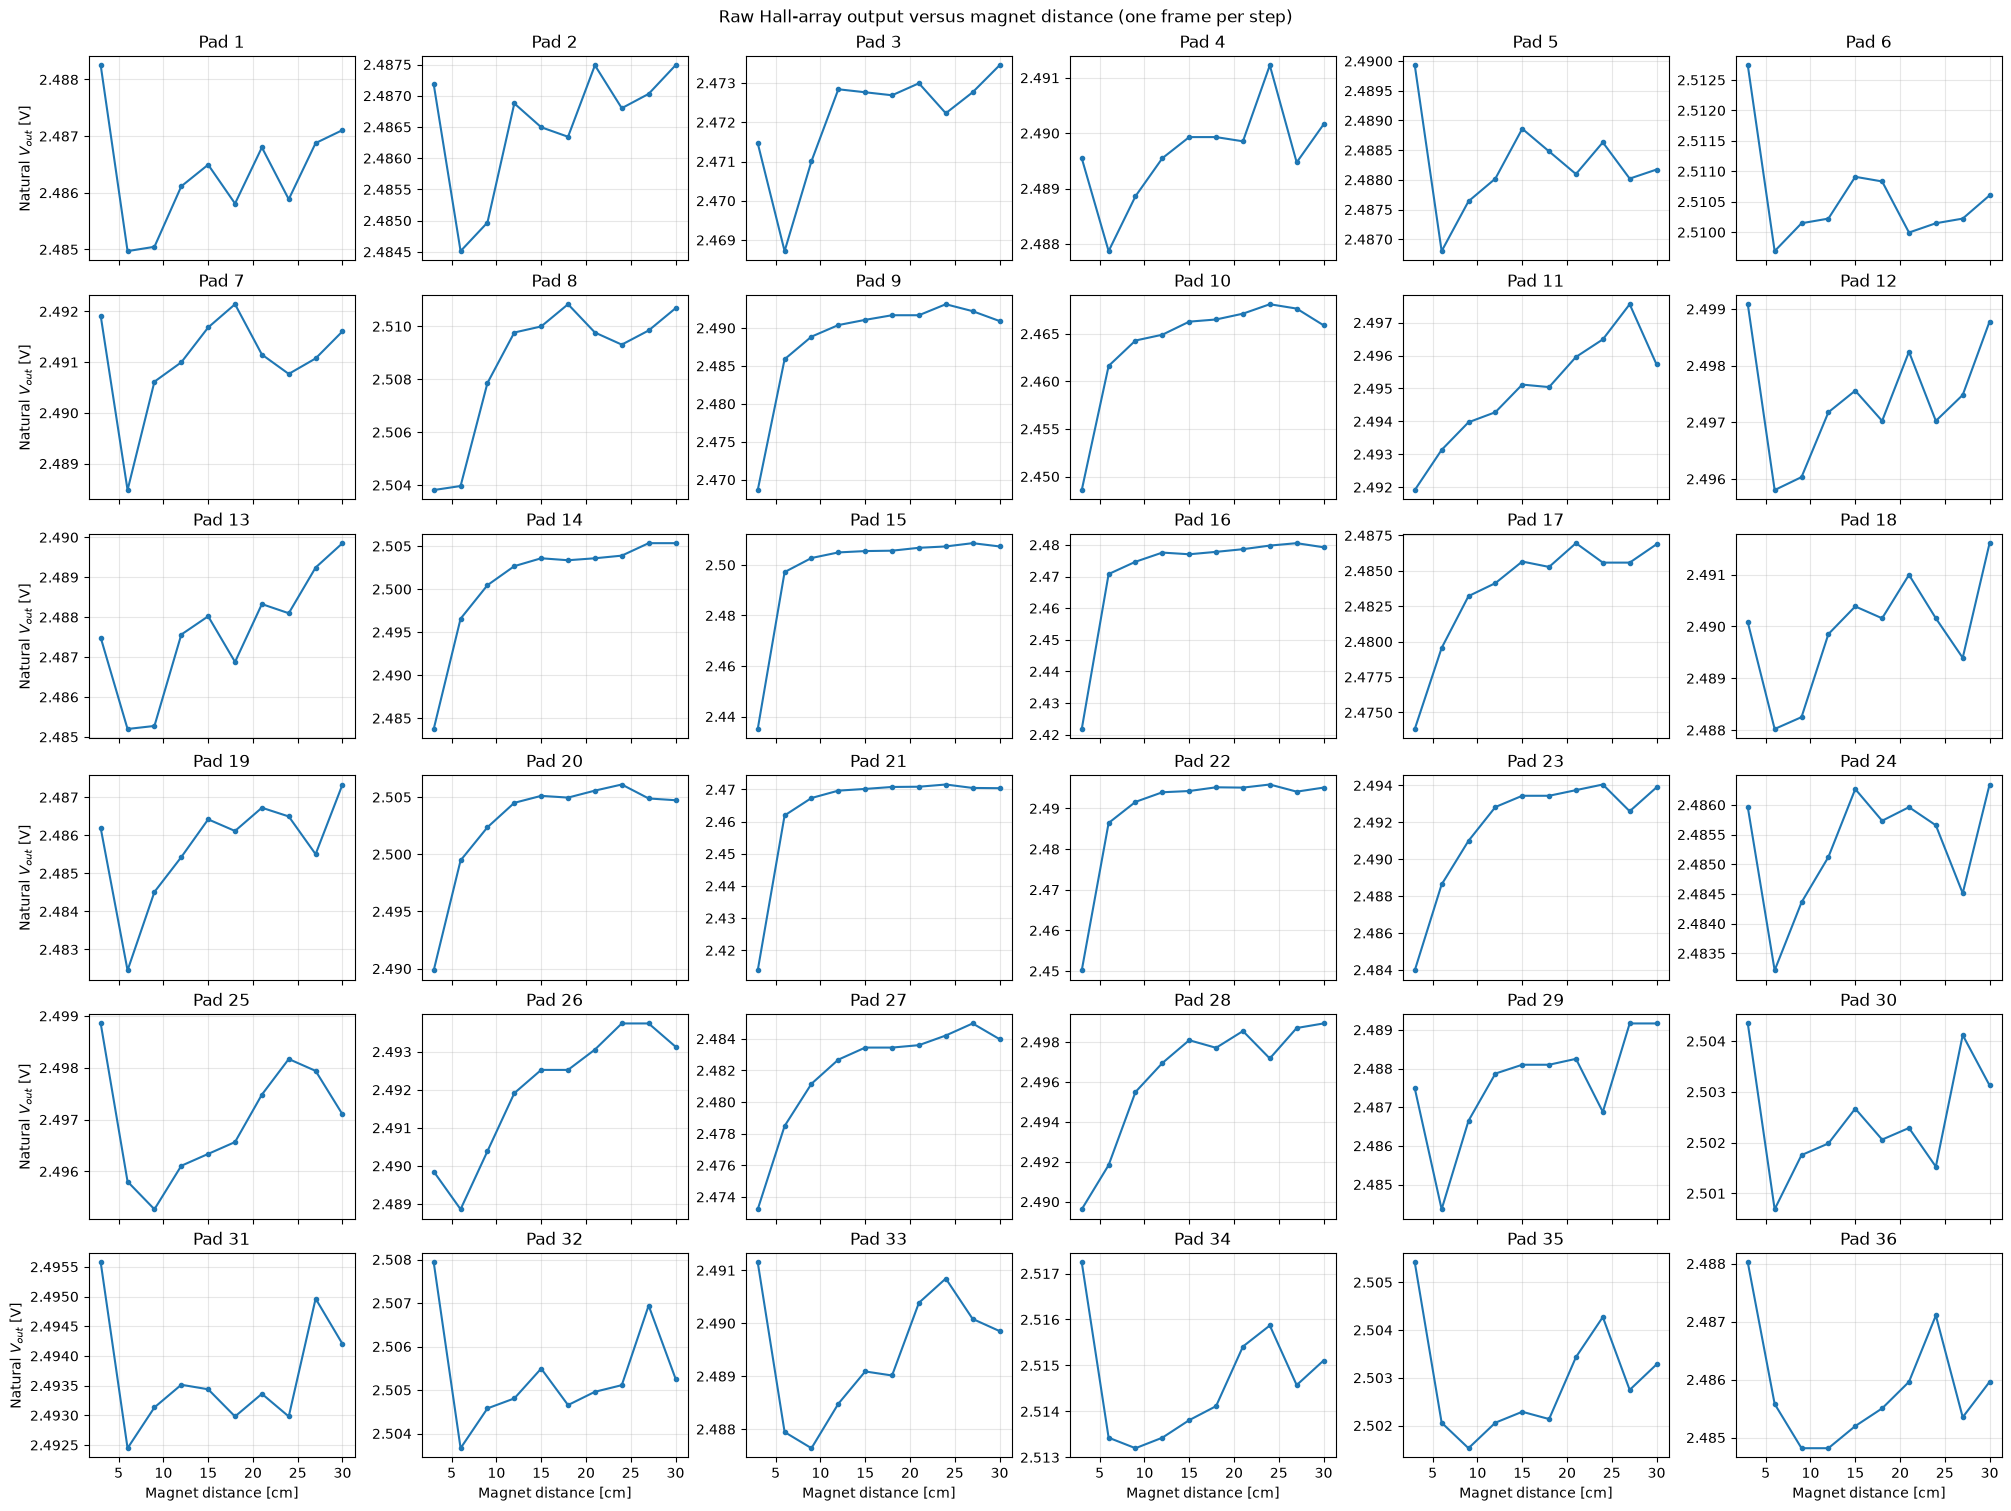

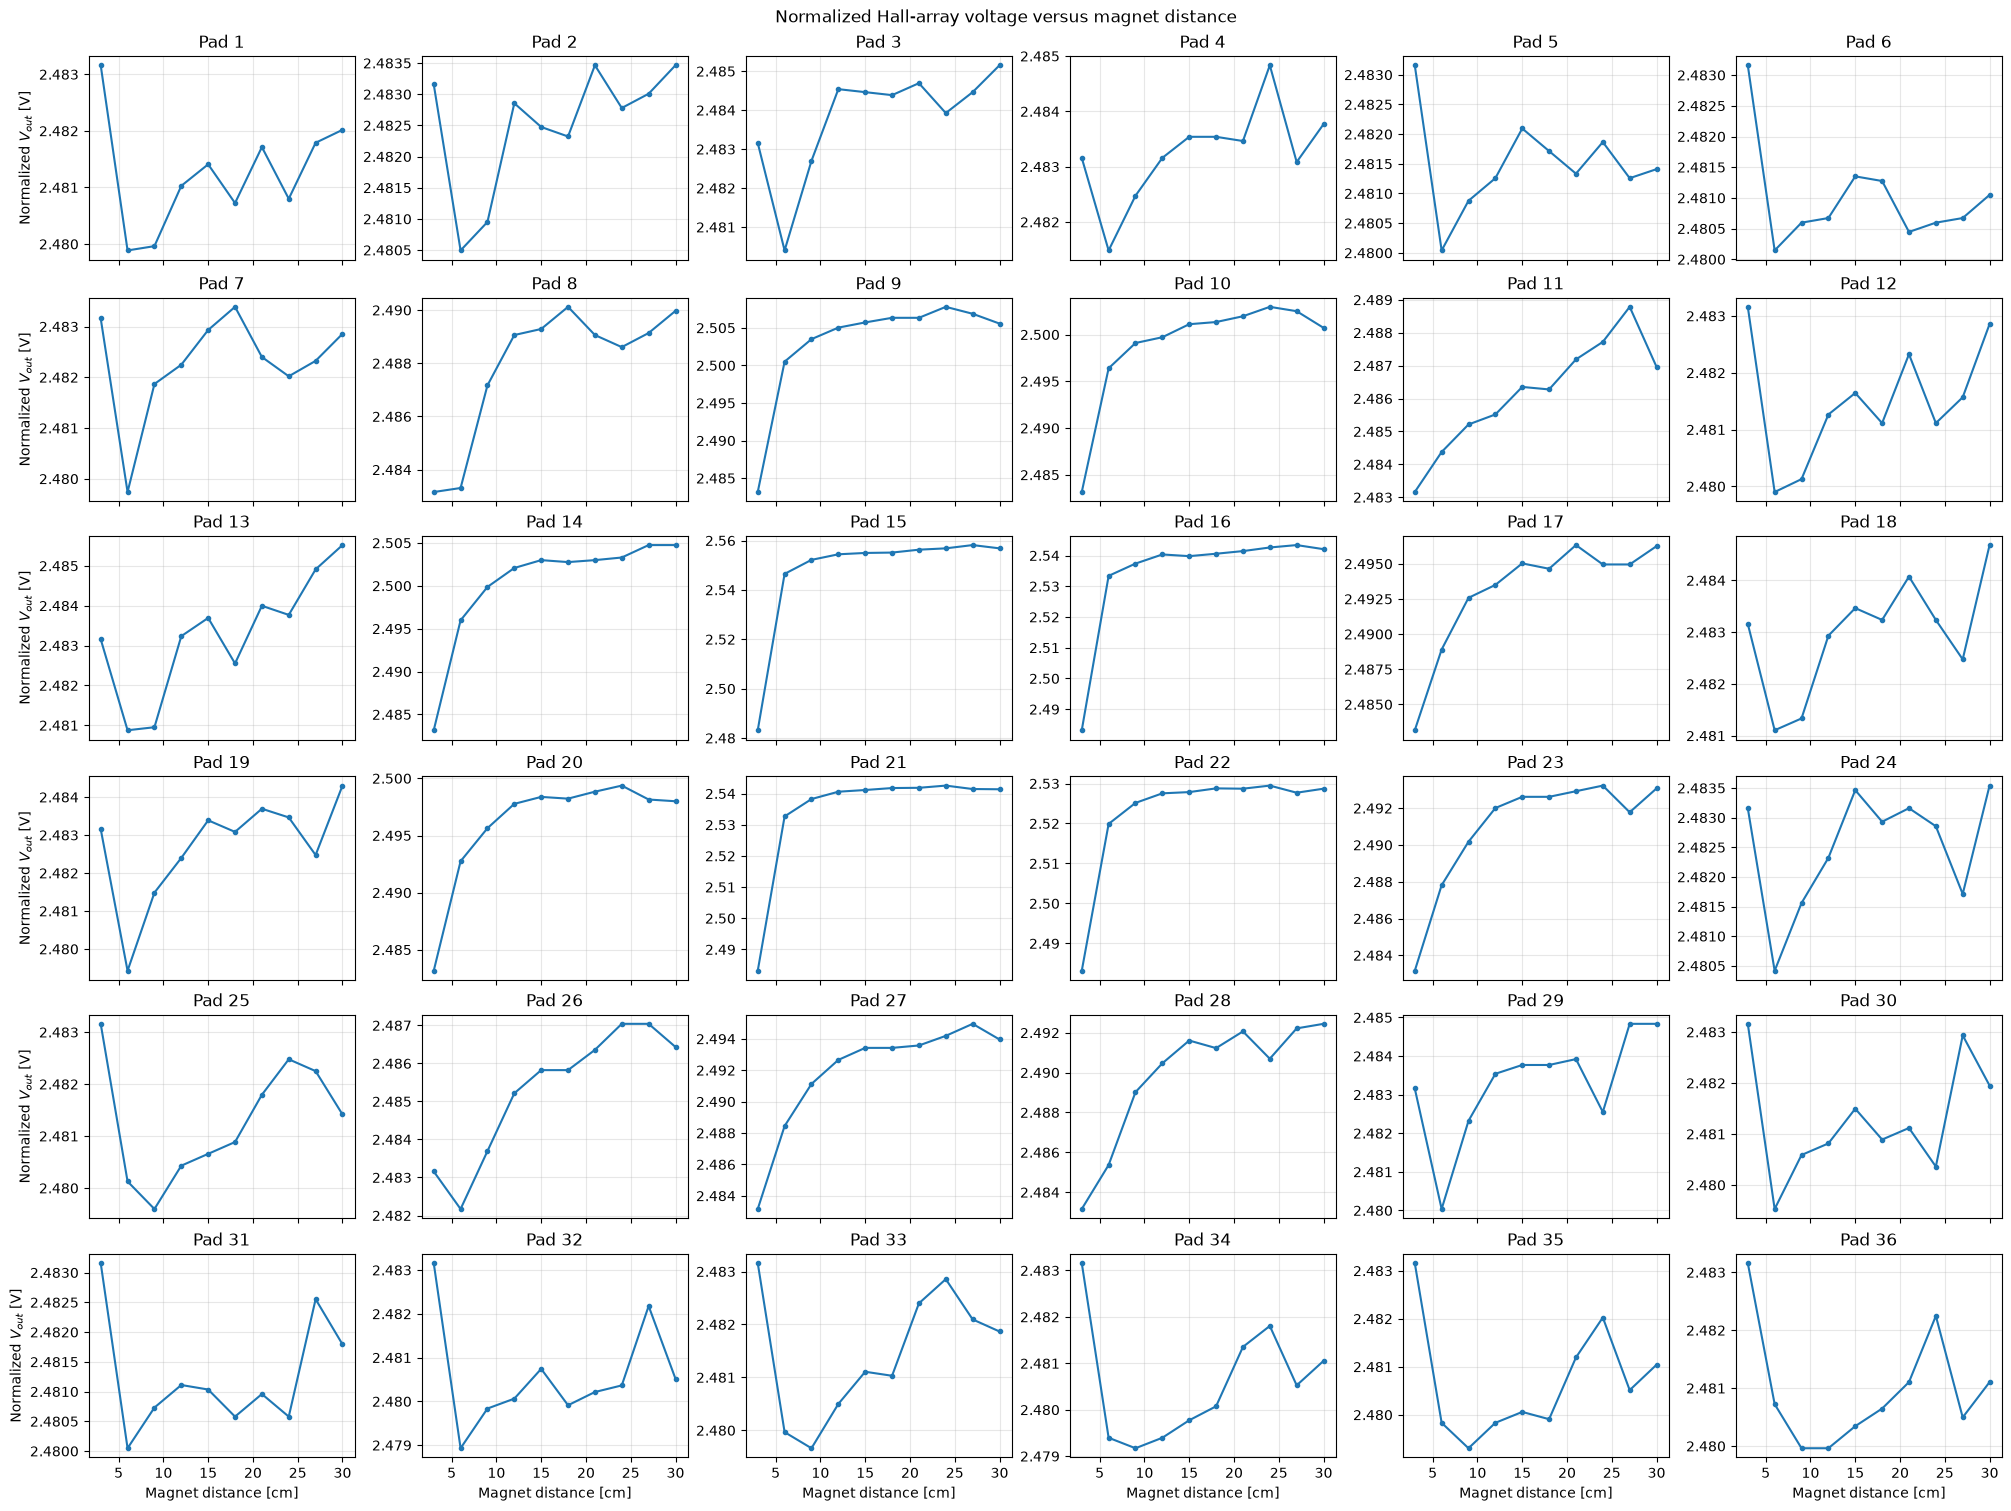

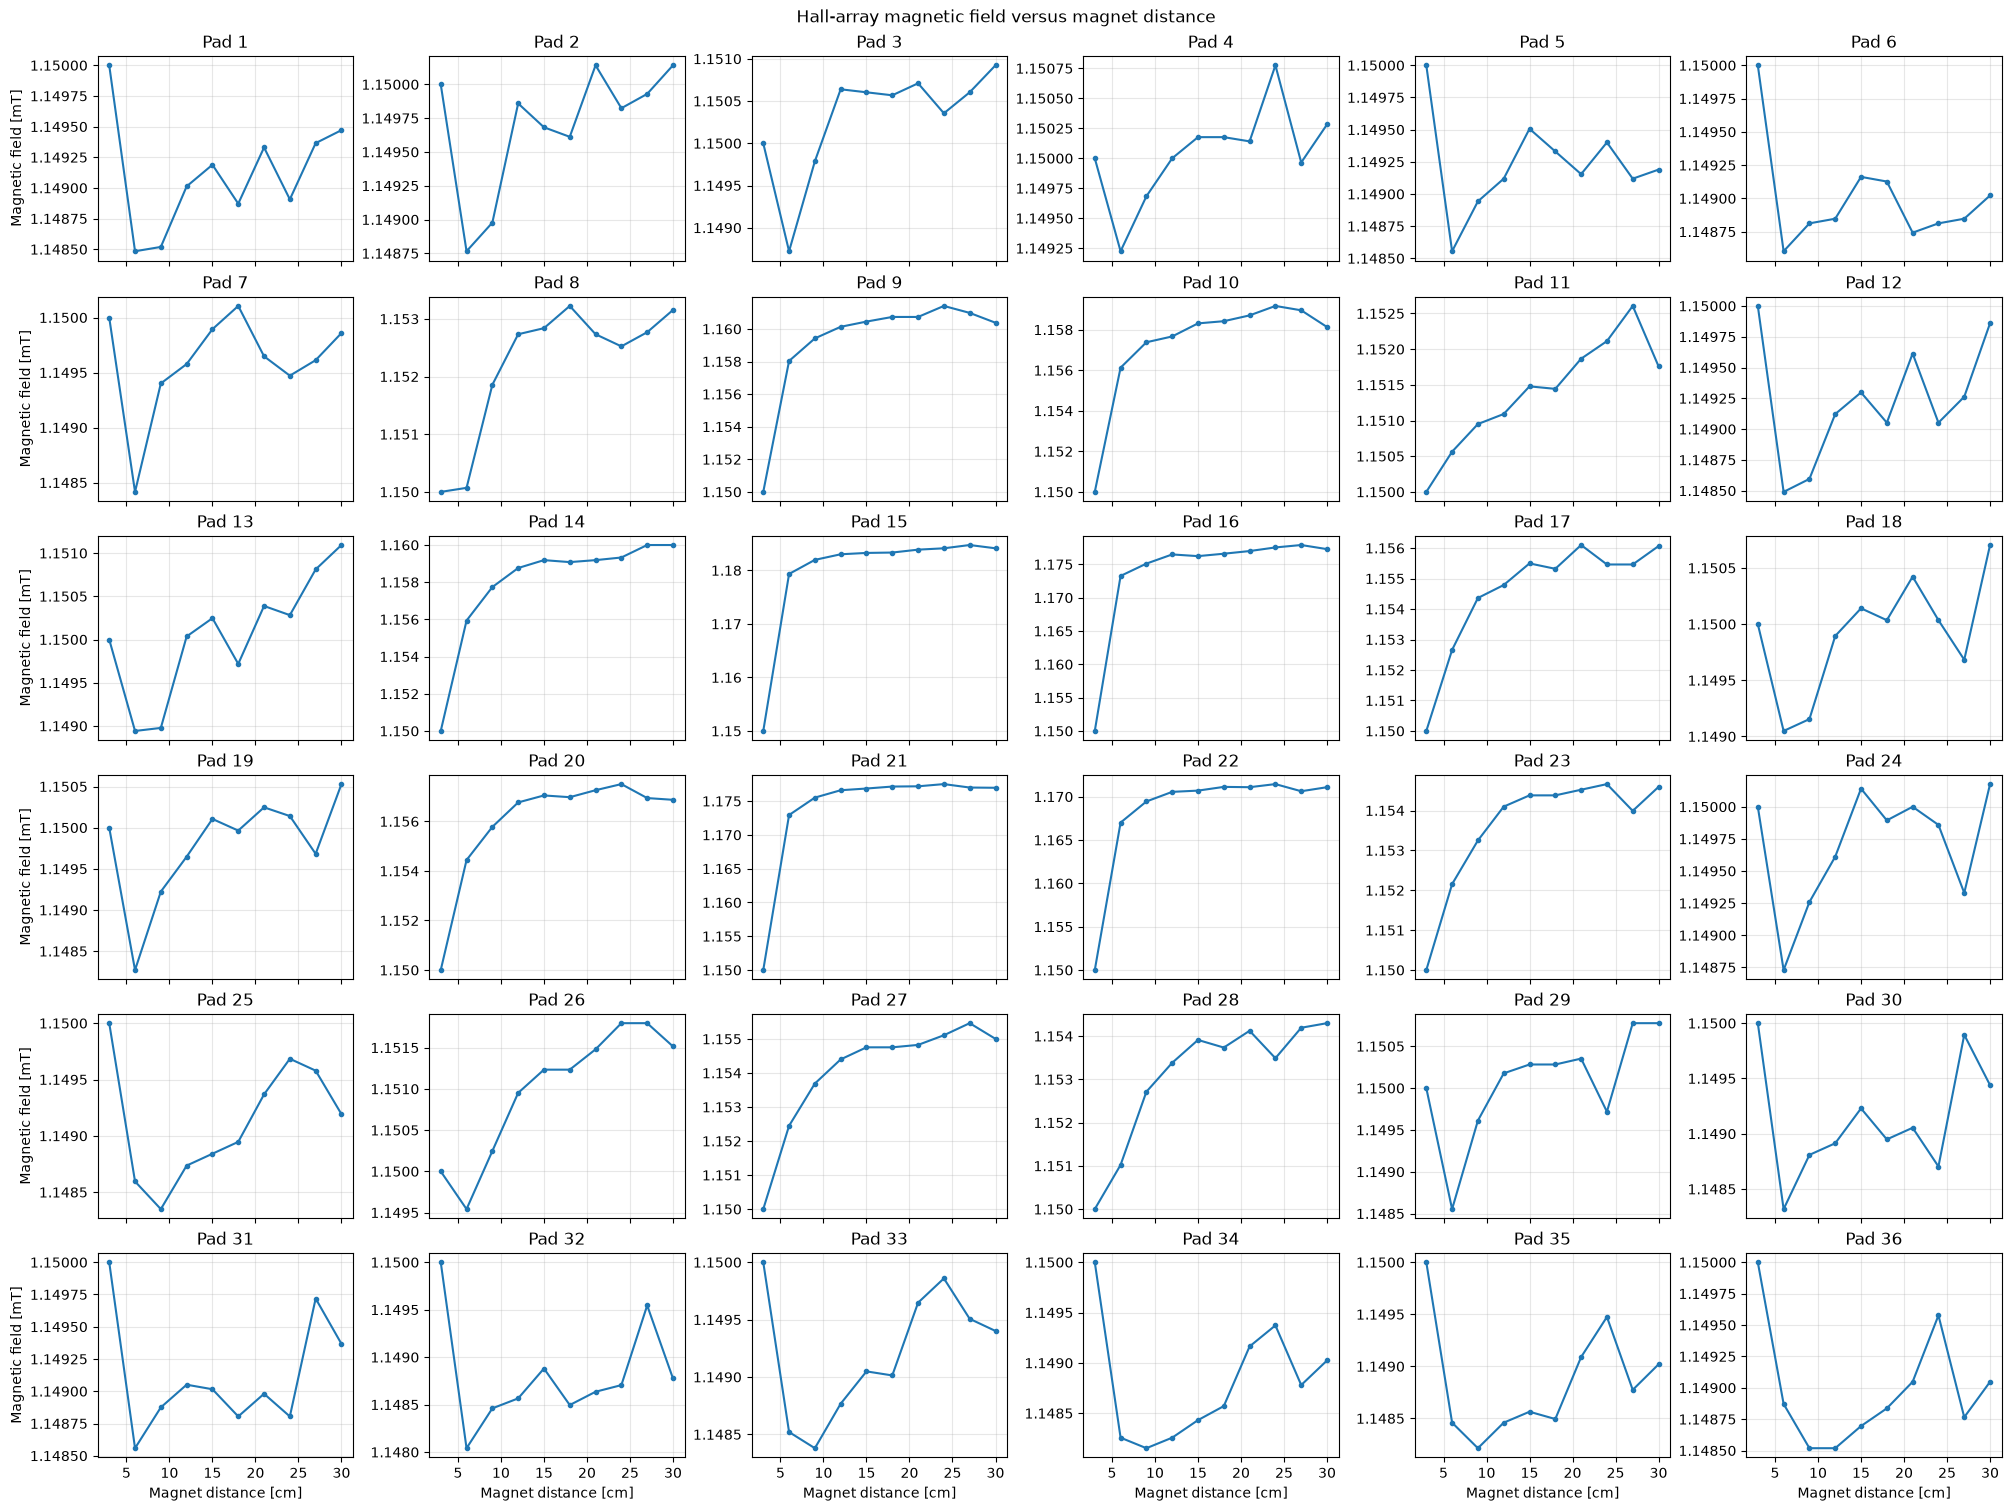

Saved hall_array_output/magnetic_field_sensitivity_36_pads.csv
Saved hall_array_output/hall_array_normalization_factors.csv
Saved hall_array_output/magnetic_field_sensitivity_vs_distance.png
Saved hall_array_output/normalized_voltage_vs_distance.png
Saved hall_array_output/magnetic_field_vs_distance.png
At 3 cm: mean raw voltage a_plus = 2.48316023 V -> 1.15 mT.
Recorded exactly one raw transmitted frame per distance; no host averaging was applied.


In [4]:
# Magnetic-field sensitivity sweep: one raw frame from every pad per distance.
# At each printed distance, place the magnet and allow one second to settle.
# Saved measurements remain raw. The live display uses display-only baseline
# removal and rolling averaging to make weak distant-field changes visible.

SENSITIVITY_START_CM = 30
SENSITIVITY_STOP_CM = 3
SENSITIVITY_SETTLE_S = 2
SENSITIVITY_FRAME_TIMEOUT_S = 5
SENSITIVITY_BASELINE_FRAMES = 500
SENSITIVITY_DISPLAY_WINDOW_FRAMES = 64


def read_one_raw_frame(ser, parser, timeout_s):
    """Return the first complete transmitted frame received after this call."""
    deadline = time.perf_counter() + timeout_s
    while time.perf_counter() < deadline:
        chunk = ser.read(max(ser.in_waiting, 1))
        if not chunk:
            continue
        frames = parser.feed(chunk)
        if frames:
            return frames[0]
    raise TimeoutError(
        f"No complete Hall-array frame received within {timeout_s:.1f} s. "
        "Check the serial connection and firmware stream."
    )


sensitivity_distance_cm = np.arange(
    SENSITIVITY_START_CM, SENSITIVITY_STOP_CM - 1, -3, dtype=np.float64
)
sensitivity_wire_values = []

# Non-blocking reads keep the live display responsive at the frame rate.
with serial.Serial(PORT, BAUDRATE, timeout=0) as ser:
    # The display follows timeseries_ambient.py: baseline reference plus a
    # rolling display average. It does not alter the raw saved measurements.
    global sensitivity_live_viewer
    sensitivity_live_viewer = SensitivityLiveSignalWindow(
        "Live Hall-array signals — magnetic-field sensitivity sweep",
        calibration_frames=SENSITIVITY_BASELINE_FRAMES,
        display_window_frames=SENSITIVITY_DISPLAY_WINDOW_FRAMES,
    )
    live_parser = FrameParser()
    print("Keep the magnet at 50 cm while the live-display baseline is collected.")
    while not sensitivity_live_viewer.calibrated:
        chunk = ser.read(max(ser.in_waiting, 1))
        if chunk:
            for raw_frame in live_parser.feed(chunk):
                sensitivity_live_viewer.update(raw_frame)
        else:
            time.sleep(0.001)
    for distance_cm in sensitivity_distance_cm:
        print(f"Place the magnet {distance_cm:.0f} cm above the array center")
        settle_deadline = time.perf_counter() + SENSITIVITY_SETTLE_S
        while time.perf_counter() < settle_deadline:
            chunk = ser.read(max(ser.in_waiting, 1))
            if chunk:
                for raw_frame in live_parser.feed(chunk):
                    sensitivity_live_viewer.update(raw_frame)
            else:
                # Yield briefly while preserving a responsive Qt event loop.
                time.sleep(0.001)

        # Discard frames that arrived during placement. The next frame is the
        # single raw measurement for this distance; it is not an average.
        ser.reset_input_buffer()
        parser = FrameParser()
        measurement_frame = read_one_raw_frame(ser, parser, SENSITIVITY_FRAME_TIMEOUT_S)
        sensitivity_live_viewer.update(measurement_frame)
        sensitivity_wire_values.append(measurement_frame)

# Close the sensitivity live-display window automatically after the 0 cm sample.
sensitivity_live_viewer.close()

sensitivity_wire_values = np.asarray(sensitivity_wire_values, dtype=np.uint16)
sensitivity_voltage_v = (
    sensitivity_wire_values.astype(np.float64) / (1 << RAW_SHIFT) * VOLTS_PER_COUNT
)

# ---------------------------------------------------------------------------
# 2.a normalization from the notes
# ---------------------------------------------------------------------------
# At d = 3 cm, let a_i be pad i's measured voltage and let
#
#                   a_plus = (1 / 36) * sum_i(a_i).
#
# The correction for pad i is c_i = a_plus / a_i.  Every voltage subsequently
# reported by that pad is normalized as V_norm_i(d) = c_i * V_raw_i(d).
# Therefore, all 36 normalized pad voltages are exactly a_plus at 3 cm.
# The notes assign that common 3 cm value to a magnetic field of 1.15 mT, so
# B_i(d) = V_norm_i(d) * (1.15 mT / a_plus).
CALIBRATION_DISTANCE_CM = 3.0
CALIBRATION_FIELD_MT = 1.15

calibration_rows = np.flatnonzero(
    np.isclose(sensitivity_distance_cm, CALIBRATION_DISTANCE_CM)
)
if calibration_rows.size != 1:
    raise RuntimeError(
        f"Expected exactly one measurement at {CALIBRATION_DISTANCE_CM:g} cm; "
        f"found {calibration_rows.size}."
    )

calibration_row = calibration_rows[0]
calibration_voltage_by_pad_v = sensitivity_voltage_v[calibration_row]
if np.any(~np.isfinite(calibration_voltage_by_pad_v)) or np.any(
    np.isclose(calibration_voltage_by_pad_v, 0.0)
):
    raise RuntimeError("The 3 cm calibration voltages must be finite and nonzero.")

calibration_mean_voltage_v = calibration_voltage_by_pad_v.mean()  # a_plus
normalization_factor = (
    calibration_mean_voltage_v / calibration_voltage_by_pad_v
)  # c_i
normalized_voltage_v = sensitivity_voltage_v * normalization_factor[np.newaxis, :]
magnetic_field_mt = (
    normalized_voltage_v
    * CALIBRATION_FIELD_MT
    / calibration_mean_voltage_v
)
magnetic_field_t = magnetic_field_mt * 1e-3
sensitivity_distance_m = sensitivity_distance_cm / 100.0

sensitivity_csv_path = OUTPUT_DIR / "magnetic_field_sensitivity_36_pads.csv"
sensitivity_header = (
    "distance_cm,distance_m,mean_normalized_voltage_v,mean_magnetic_field_mt,"
    + ",".join(
        f"pad_{index:02d}_raw_voltage_v" for index in range(1, NUM_CHANNELS + 1)
    )
    + ","
    + ",".join(
        f"pad_{index:02d}_normalized_voltage_v"
        for index in range(1, NUM_CHANNELS + 1)
    )
    + ","
    + ",".join(
        f"pad_{index:02d}_magnetic_field_mt"
        for index in range(1, NUM_CHANNELS + 1)
    )
)
np.savetxt(
    sensitivity_csv_path,
    np.column_stack(
        (
            sensitivity_distance_cm,
            sensitivity_distance_m,
            normalized_voltage_v.mean(axis=1),
            magnetic_field_mt.mean(axis=1),
            sensitivity_voltage_v,
            normalized_voltage_v,
            magnetic_field_mt,
        )
    ),
    delimiter=",",
    header=sensitivity_header,
    comments="",
)

# Save the 36 correction factors so the normalization is reproducible.
sensitivity_normalization_csv_path = OUTPUT_DIR / "hall_array_normalization_factors.csv"
np.savetxt(
    sensitivity_normalization_csv_path,
    np.column_stack(
        (
            np.arange(1, NUM_CHANNELS + 1),
            calibration_voltage_by_pad_v,
            normalization_factor,
            np.full(NUM_CHANNELS, calibration_mean_voltage_v),
            np.full(NUM_CHANNELS, CALIBRATION_FIELD_MT),
        )
    ),
    delimiter=",",
    header=(
        "pad,raw_voltage_at_3cm_v,normalization_factor,"
        "target_normalized_voltage_v,calibration_field_mt"
    ),
    comments="",
)

# One panel per pad: natural raw output voltage versus magnet-to-array distance.
fig, axes = plt.subplots(6, 6, figsize=(20, 15), sharex=True, constrained_layout=True)
for channel, ax in enumerate(axes.flat):
    ax.plot(sensitivity_distance_cm, sensitivity_voltage_v[:, channel], marker="o", ms=3)
    ax.set_title(f"Pad {channel + 1}")
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()  # 30 cm is first; 3 cm is the final, nearest position.
for ax in axes[-1, :]:
    ax.set_xlabel("Magnet distance [cm]")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Natural $V_{out}$ [V]")
fig.suptitle("Raw Hall-array output versus magnet distance (one frame per step)")
sensitivity_distance_plot_path = OUTPUT_DIR / "magnetic_field_sensitivity_vs_distance.png"
fig.savefig(sensitivity_distance_plot_path, dpi=200, bbox_inches="tight")
plt.show()

# One panel per pad: normalized voltage versus distance.
fig, axes = plt.subplots(6, 6, figsize=(20, 15), sharex=True, constrained_layout=True)
for channel, ax in enumerate(axes.flat):
    ax.plot(sensitivity_distance_cm, normalized_voltage_v[:, channel], marker="o", ms=3)
    ax.set_title(f"Pad {channel + 1}")
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()
for ax in axes[-1, :]:
    ax.set_xlabel("Magnet distance [cm]")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Normalized $V_{out}$ [V]")
fig.suptitle("Normalized Hall-array voltage versus magnet distance")
sensitivity_normalized_plot_path = OUTPUT_DIR / "normalized_voltage_vs_distance.png"
fig.savefig(sensitivity_normalized_plot_path, dpi=200, bbox_inches="tight")
plt.show()

# One panel per pad: magnetic field obtained from the 3 cm, 1.15 mT calibration.
fig, axes = plt.subplots(6, 6, figsize=(20, 15), sharex=True, constrained_layout=True)
for channel, ax in enumerate(axes.flat):
    ax.plot(sensitivity_distance_cm, magnetic_field_mt[:, channel], marker="o", ms=3)
    ax.set_title(f"Pad {channel + 1}")
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()
for ax in axes[-1, :]:
    ax.set_xlabel("Magnet distance [cm]")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Magnetic field [mT]")
fig.suptitle("Hall-array magnetic field versus magnet distance")
sensitivity_field_plot_path = OUTPUT_DIR / "magnetic_field_vs_distance.png"
fig.savefig(sensitivity_field_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved {sensitivity_csv_path}")
print(f"Saved {sensitivity_normalization_csv_path}")
print(f"Saved {sensitivity_distance_plot_path}")
print(f"Saved {sensitivity_normalized_plot_path}")
print(f"Saved {sensitivity_field_plot_path}")
print(
    f"At {CALIBRATION_DISTANCE_CM:g} cm: mean raw voltage "
    f"a_plus = {calibration_mean_voltage_v:.9g} V -> "
    f"{CALIBRATION_FIELD_MT:g} mT."
)
print("Recorded exactly one raw transmitted frame per distance; no host averaging was applied.")
